# CCO04: Redo clustering and everything downstream

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata
import os
import glob
import scipy

In [2]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO04

In [3]:
DATA_DIR = '/home/herbert/PyProjects/cocultured_organ/data/240603'
OUT_DIR = '/home/herbert/PyProjects/cocultured_organ/workspace/CCO04'

## 1. Coembed and Cluster

In [4]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO04/adata

In [5]:
%%capture

for d1 in glob.glob(f"{DATA_DIR}/*"):
    if not os.path.isdir(d1):
        continue
    else:
        sample_name = d1.split('/')[-1]
    
    # load h5 file
    adata = sc.read_10x_h5(f'{d1}/filtered_feature_bc_matrix.h5')
    adata.var_names_make_unique()
    
    # qc
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
    
    # processing 
    sc.pp.filter_cells(adata, min_genes=200)
    # sc.pp.filter_genes(adata, min_cells=3)
    adata = adata[adata.obs.pct_counts_mt < 10, :].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=5000)
    # adata.raw = adata
    
    # adata = adata[:, adata.var['highly_variable']]
    # sc.pp.scale(adata, max_value=10)
    
    # prepare umap
    # sc.tl.pca(adata, svd_solver='arpack')
    # sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    # sc.tl.leiden(adata)
    # sc.tl.umap(adata)
    
    # write to h5ad
    adata.write(f'{OUT_DIR}/adata/{sample_name}.h5ad')

In [6]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO04/coembed

In [7]:
adata_bho = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__BHO-JW-052224.h5ad')
adata_bvo = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__BVO-JW-052224.h5ad')
adata_cm3b = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__CM3B-JW-052224.h5ad')
adata_cm3o = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__CM3O-JW-052224.h5ad')
adata_ho = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__HO-JW-052224.h5ad')

In [8]:
adata_all = adata_bho.concatenate(adata_bvo, adata_cm3b, adata_cm3o, adata_ho, batch_key='batch')

batch_mapping = {
    '0': 'BHO',
    '1': 'BVO',
    '2': 'CM3B',
    '3': 'CM3O',
    '4': 'HO'
}

adata_all.obs['batch'] = adata_all.obs['batch'].map(batch_mapping)
# sc.pp.normalize_total(adata_all)
# sc.pp.log1p(adata_all)
# sc.pp.scale(adata_all, max_value=10)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [9]:
# proporgate knn graph

n_neighbors = 1000
sc.tl.pca(adata_all, svd_solver='arpack', n_comps=100, random_state=42)
sc.pp.neighbors(adata_all, n_pcs=100, n_neighbors=n_neighbors, random_state=42)
sc.tl.leiden(adata_all, resolution=1.5)
sc.tl.umap(adata_all)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
adata_all.write(f'{OUT_DIR}/coembed/SC160__ALL-JW-052224.h5ad')

In [11]:
for exp in ['BHO','BVO','CM3B','CM3O','HO']:
    adata_all[adata_all.obs['batch'] == exp, :].write(f'{OUT_DIR}/coembed/SC160__{exp}-JW-052224.h5ad')

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


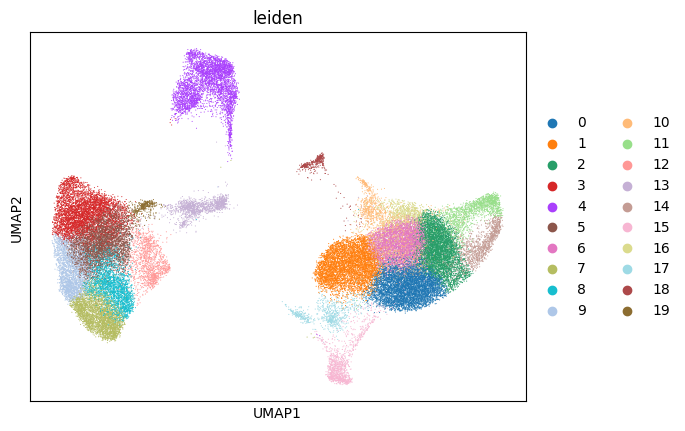

In [12]:
sc.pl.umap(adata_all, color='leiden', cmap='tab20')

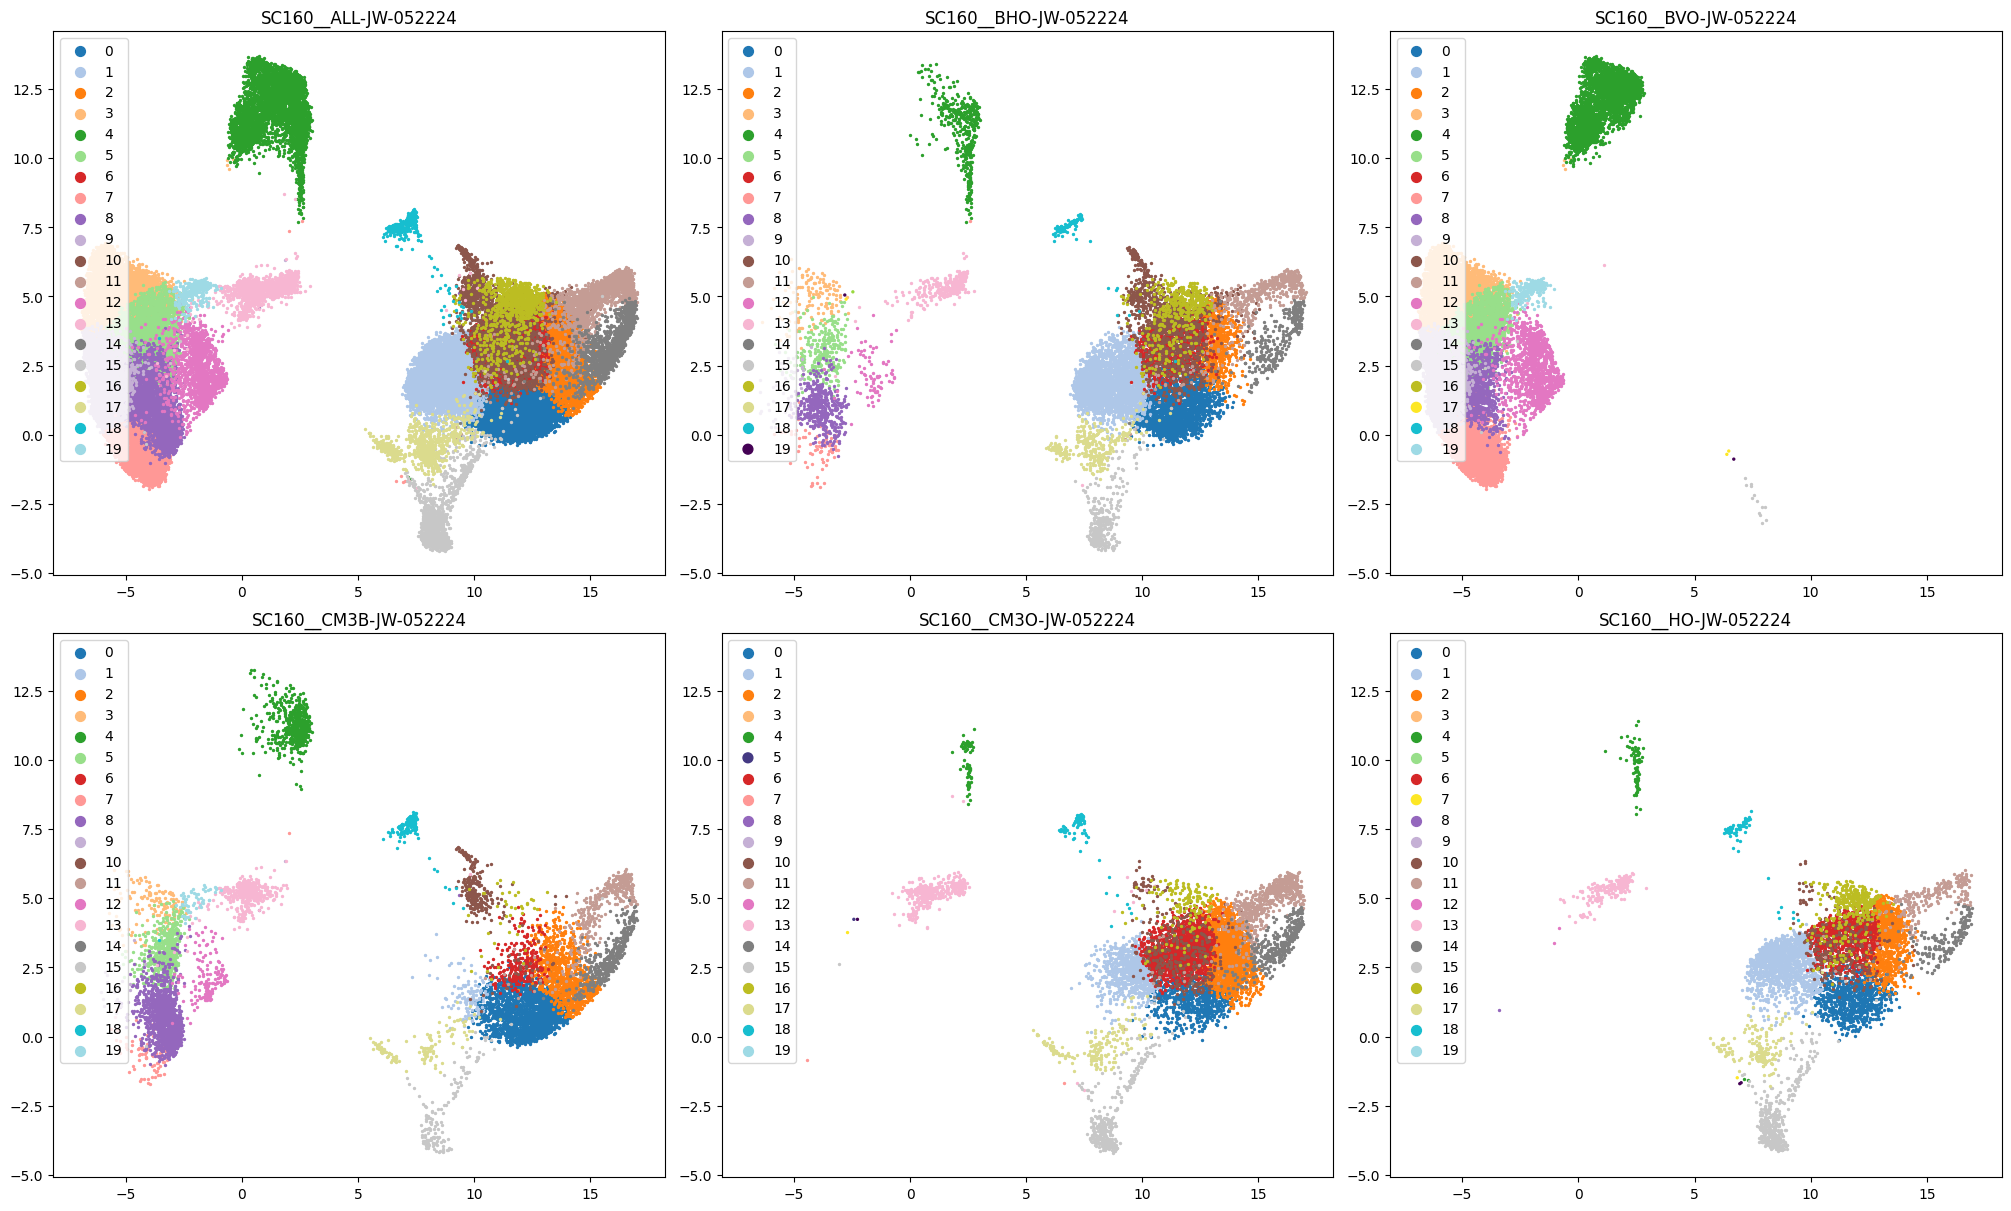

In [15]:
%%capture --no-display

colors = plt.get_cmap('tab20').colors
fig, axs = plt.subplots(2, 3, figsize=(20,12), layout="constrained")
axs = axs.flatten()

for i, f in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad')):
    sample_name = f.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f)
    # sc.tl.pca(adata, svd_solver='arpack')
    # sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    # sc.tl.leiden(adata, resolution=0.5)
    # adata.write(f'{OUT_DIR}/coembed/{sample_name}.h5ad.clustered')
    
    # axs[i] = sc.pl.umap(adata, color='leiden', ax=axs[i], title=sample_name, show=False, cmap='tab10')
    for j in range(0, 20):
        axs[i].scatter(adata.obsm['X_umap'][adata.obs['leiden'] == str(j), 0], 
                       adata.obsm['X_umap'][adata.obs['leiden'] == str(j), 1], 
                       c=colors[j], s=2, label=str(j))
        axs[i].legend(loc='upper left', markerscale=5)
        axs[i].set_title(sample_name)
        
    if i == 0:
        xlim_ref = axs[i].get_xlim()
        ylim_ref = axs[i].get_ylim()
    else:
        axs[i].set_xlim(xlim_ref)
        axs[i].set_ylim(ylim_ref)
    
plt.savefig(f'{OUT_DIR}/coembed/umaps.png')
plt.show()

## 2. Visualize marker positive cells

In [16]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO04/gene_marker_umap

In [17]:
%%capture --no-display

marker_genes = ['PECAM1', 'CDH5', 
                'PDGFRB', 'ACTA2', 
                'TNNI1', 'TNNC1', 'TNNT2', 
                'NPPA', 'NPPB', 'MYH7', 'MYL2']

for gene in marker_genes:

    try:
        
        fig, axs = plt.subplots(2, 3, figsize=(15,6), layout="constrained")
        axs = axs.flatten()

        for i, f in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad')):
            sample_name = f.split('/')[-1].strip('.h5ad')
            adata = sc.read_h5ad(f)
            axs[i] = sc.pl.umap(adata, color=gene, ax=axs[i], title=sample_name, show=False)
            if i == 0:
                xlim_ref = axs[i].get_xlim()
                ylim_ref = axs[i].get_ylim()
            else:
                axs[i].set_xlim(xlim_ref)
                axs[i].set_ylim(ylim_ref)

        plt.savefig(f'{OUT_DIR}/gene_marker_umap/{gene}.png')
    
    except:
        continue
        
    finally:
        plt.close()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

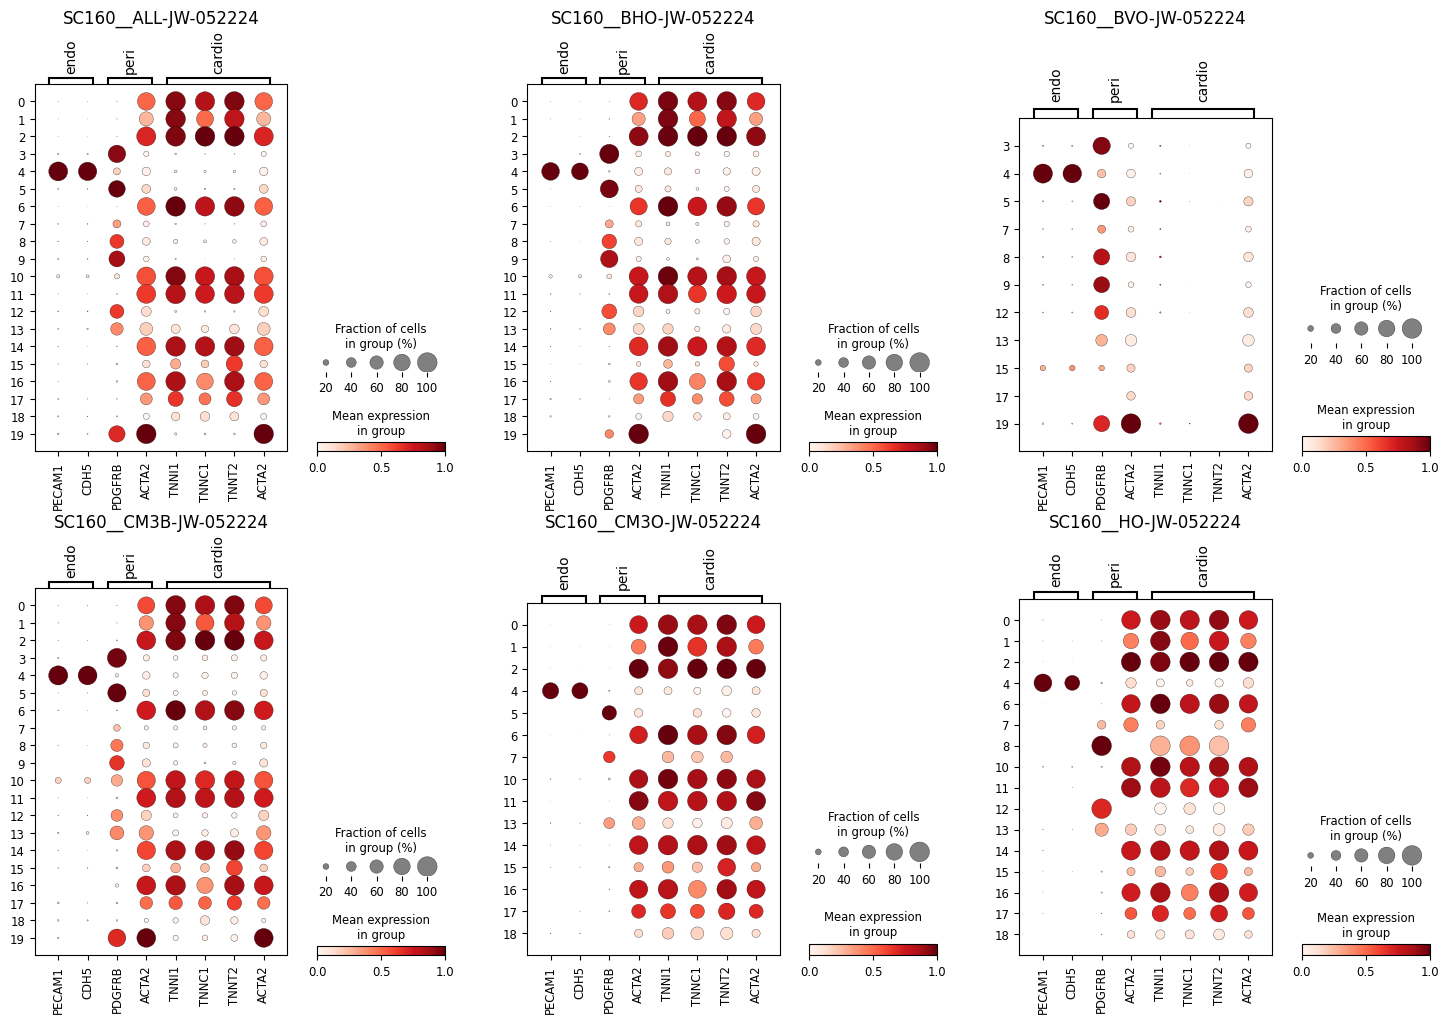

In [18]:
marker_dict = {
    'endo': ['PECAM1', 'CDH5'], 
    'peri': ['PDGFRB', 'ACTA2'], 
    'cardio': ['TNNI1', 'TNNC1', 'TNNT2', 'ACTA2']
}

fig, axs = plt.subplots(2, 3, figsize=(18,12), layout="constrained")
axs = axs.flatten()
# axs[-1].remove()

for i, d1 in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad')):
    # try:
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, marker_dict, groupby="leiden", standard_scale="var", ax=axs[i], title=sample_name, show=False)
    # sc.pl.dotplot(adata, var_names=marker_genes, groupby='leiden', ax=axs[i], title=sample_name, show=False)
    # except:
    #     continue
    
plt.savefig(f'{OUT_DIR}/gene_marker_umap/dotplots.png')
plt.show()

## 3. Label clusters

In [19]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO04/celltype_label

In [22]:
samples = ['BVO','HO','CM3O','BHO','CM3B']

celltypes_dict = {
    '0': 'cardio', 
    '1': 'cardio',
    '2': 'cardio',
    '3': 'peri',
    '4': 'endo',
    '5': 'peri',
    '6': 'cardio',
    '7': 'other',
    '8': 'other',
    '9': 'peri',
    '10': 'cardio',
    '11': 'cardio',
    '12': 'other',
    '13': 'other',
    '14': 'cardio',
    '15': 'other',
    '16': 'cardio',
    '17': 'cardio',
    '18': 'other',
    '19': 'peri',
}

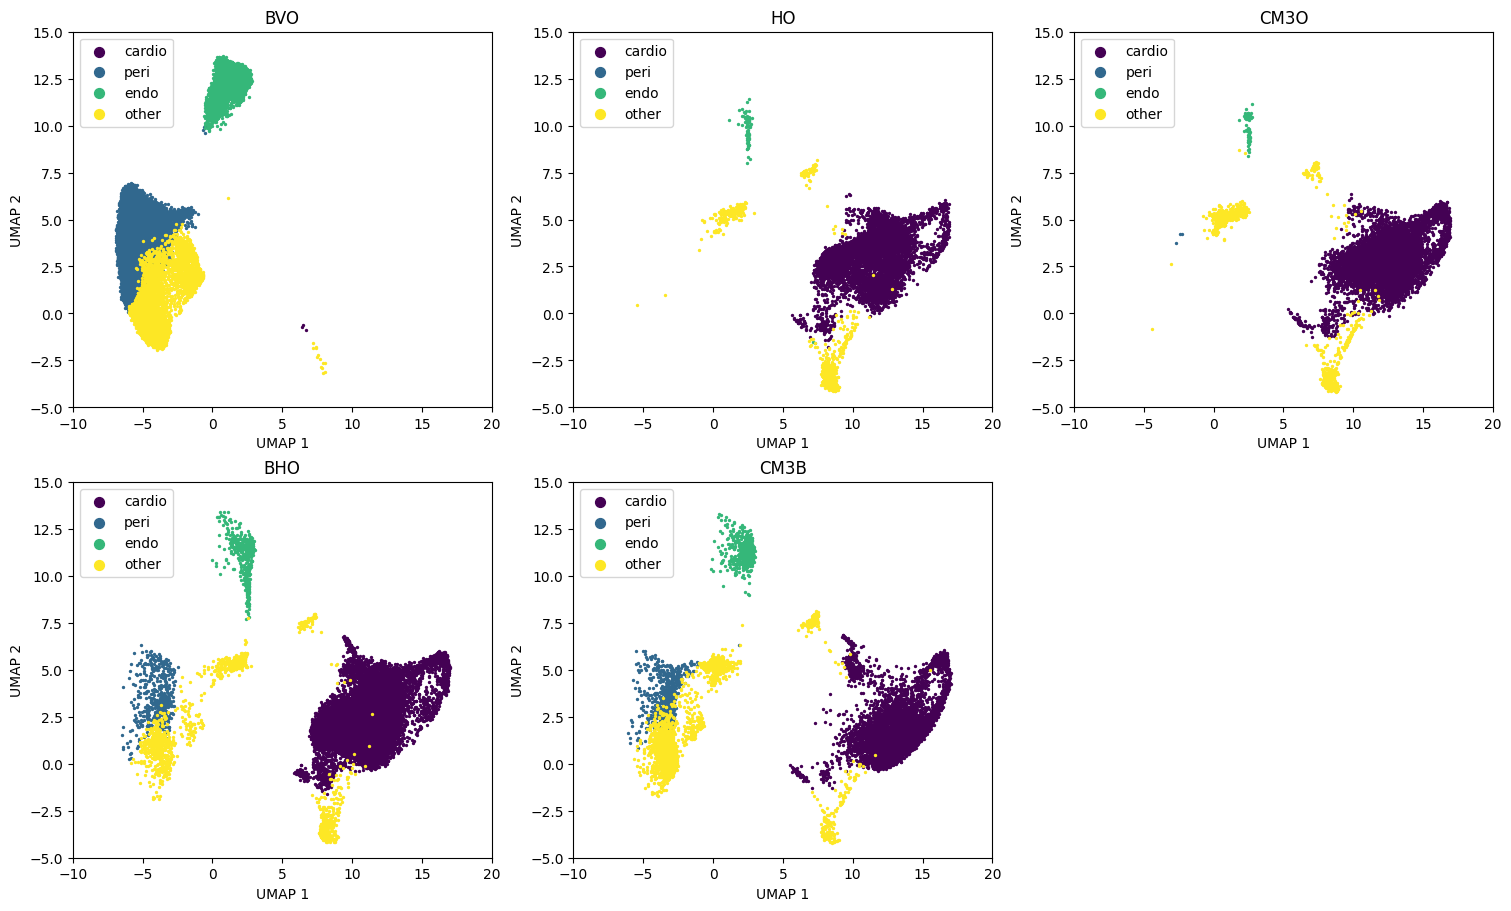

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(15,9), layout="constrained")
axs = axs.flatten()
axs[-1].remove()

cell_types = ['cardio','peri','endo','other']
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(cell_types)))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{OUT_DIR}/coembed/SC160__{sample}-JW-052224.h5ad')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
    adata.write(f'{OUT_DIR}/celltype_label/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='upper left', markerscale=5)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-10, 20])
    axs[i].set_ylim([-5, 15])
    
plt.savefig(f'{OUT_DIR}/celltype_label/umap.png')
plt.show()

## 4. Differential Expresssion

In [5]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO04/volcano

In [6]:
adata_BVO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/BVO.h5ad')
adata_HO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/HO.h5ad')
adata_CM3O = sc.read_h5ad(f'{OUT_DIR}/celltype_label/CM3O.h5ad')
adata_BHO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/BHO.h5ad')
adata_CM3B = sc.read_h5ad(f'{OUT_DIR}/celltype_label/CM3B.h5ad')

In [37]:
def volcano_plot(adata1, adata2, celltype, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1.5
    pvalue_thres = 5
    
    if np.any(adata1.var_names != adata2.var_names):
        raise ValueError('adata var names not unified')
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X[adata1.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT
    data2 = adata2.X[adata2.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
    plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

### 4.1 pericyte

/tmp/ipykernel_1419917/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


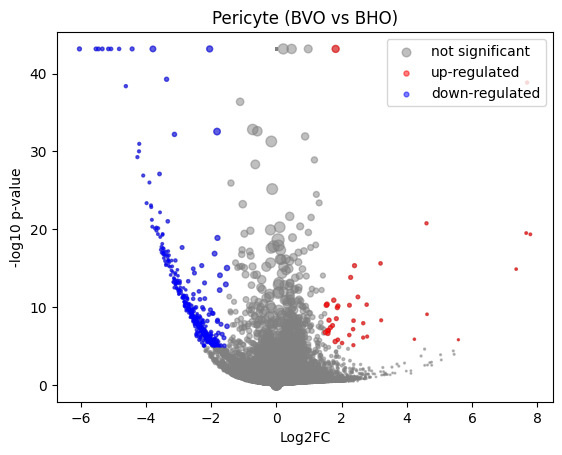

In [38]:
volcano_plot(adata_BVO, 
             adata_BHO, 
             'peri', 
             'Pericyte (BVO vs BHO)', 
             save=f'{OUT_DIR}/volcano/peri.BVO.BHO.png', 
             save_tsv=f'{OUT_DIR}/volcano/peri.BVO.BHO.tsv')

/tmp/ipykernel_1419917/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


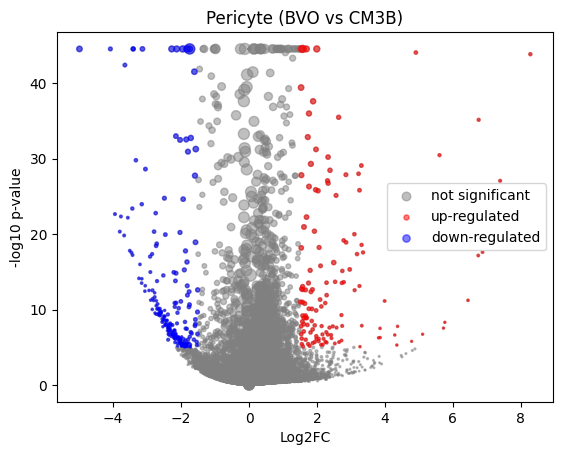

In [39]:
volcano_plot(adata_BVO, 
             adata_CM3B, 
             'peri', 
             'Pericyte (BVO vs CM3B)', 
             save=f'{OUT_DIR}/volcano/peri.BVO.CM3B.png', 
             save_tsv=f'{OUT_DIR}/volcano/peri.BVO.CM3B.tsv')

/tmp/ipykernel_1419917/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


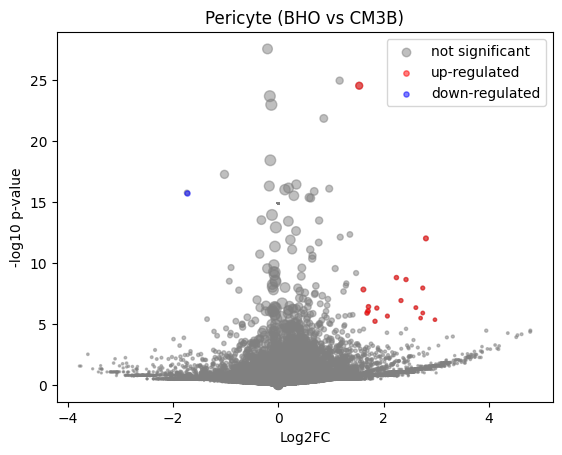

In [40]:
volcano_plot(adata_BHO, 
             adata_CM3B, 
             'peri', 
             'Pericyte (BHO vs CM3B)', 
             save=f'{OUT_DIR}/volcano/peri.BHO.CM3B.png', 
             save_tsv=f'{OUT_DIR}/volcano/peri.BHO.CM3B.tsv')

### 4.2 endothelial cell

/tmp/ipykernel_1419917/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


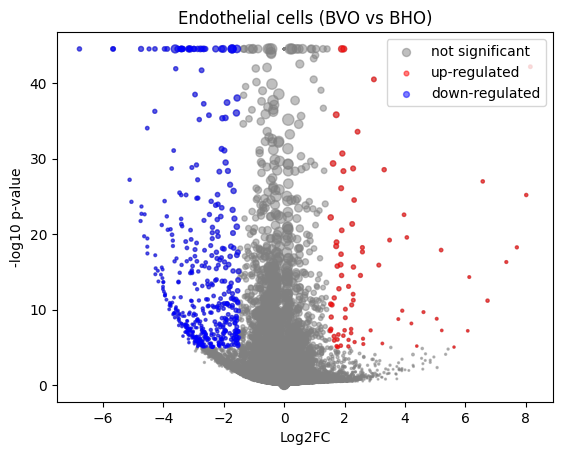

In [41]:
volcano_plot(adata_BVO, 
             adata_BHO, 
             'endo', 
             'Endothelial cells (BVO vs BHO)', 
             save=f'{OUT_DIR}/volcano/endo.BVO.BHO.png', 
             save_tsv=f'{OUT_DIR}/volcano/endo.BVO.BHO.tsv')

/tmp/ipykernel_1419917/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


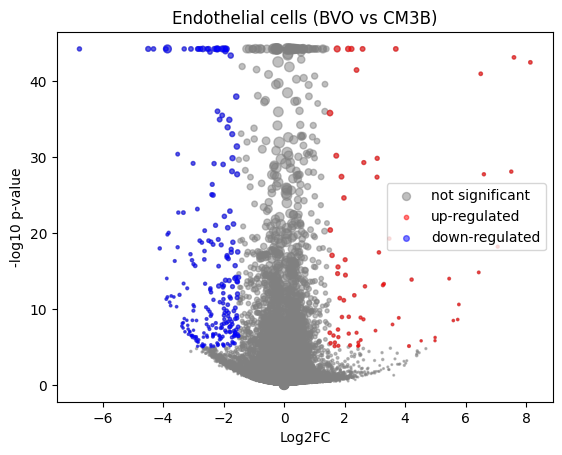

In [42]:
volcano_plot(adata_BVO, 
             adata_CM3B, 
             'endo', 
             'Endothelial cells (BVO vs CM3B)', 
             save=f'{OUT_DIR}/volcano/endo.BVO.CM3B.png', 
             save_tsv=f'{OUT_DIR}/volcano/endo.BVO.CM3B.tsv')

/tmp/ipykernel_1419917/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


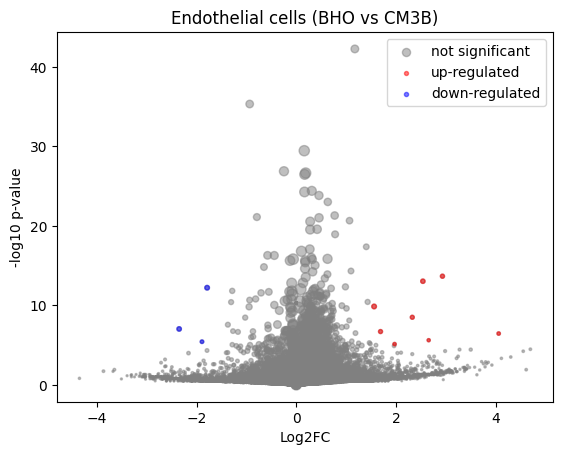

In [43]:
volcano_plot(adata_BHO, 
             adata_CM3B, 
             'endo', 
             'Endothelial cells (BHO vs CM3B)', 
             save=f'{OUT_DIR}/volcano/endo.BHO.CM3B.png', 
             save_tsv=f'{OUT_DIR}/volcano/endo.BHO.CM3B.tsv')

### 4.3 cardiomyocyte

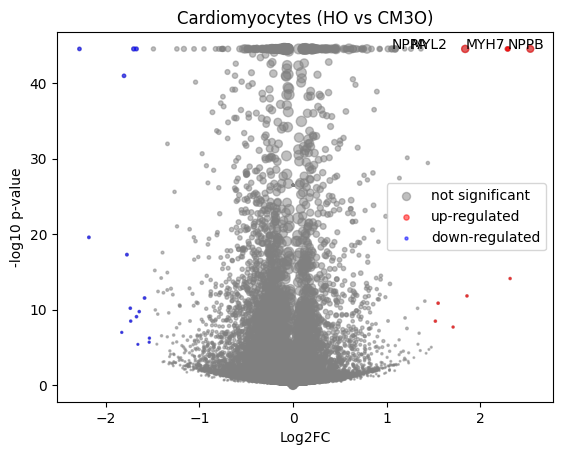

In [44]:
volcano_plot(adata_HO, 
             adata_CM3O, 
             'cardio', 
             'Cardiomyocytes (HO vs CM3O)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{OUT_DIR}/volcano/cardio.HO.CM3O.png', 
             save_tsv=f'{OUT_DIR}/volcano/cardio.HO.CM3O.tsv')

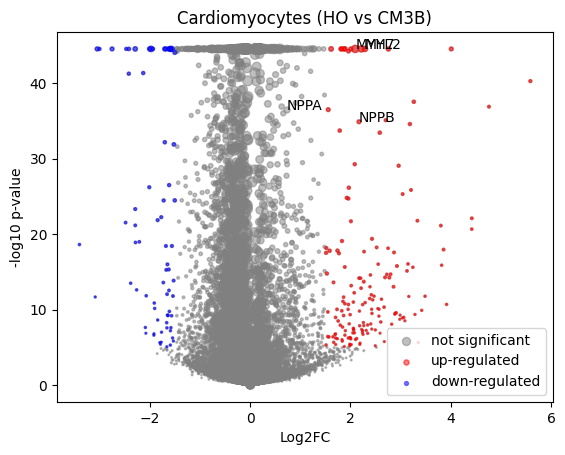

In [45]:
volcano_plot(adata_HO, 
             adata_CM3B, 
             'cardio', 
             'Cardiomyocytes (HO vs CM3B)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{OUT_DIR}/volcano/cardio.HO.CM3B.png', 
             save_tsv=f'{OUT_DIR}/volcano/cardio.HO.CM3B.tsv')

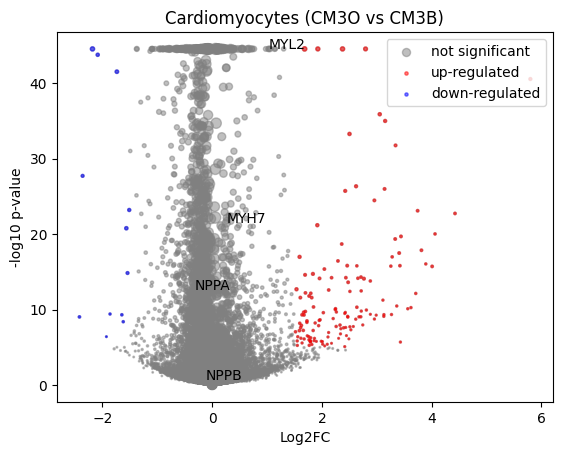

False Positive Rate: 0.004043605365973607


In [46]:
volcano_plot(adata_CM3O, 
             adata_CM3B, 
             'cardio', 
             'Cardiomyocytes (CM3O vs CM3B)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{OUT_DIR}/volcano/cardio.CM3O.CM3B.png', 
             save_tsv=f'{OUT_DIR}/volcano/cardio.CM3O.CM3B.tsv')

df_deg = pd.read_csv('~/PyProjects/cocultured_organ/workspace/CCO04/volcano/cardio.CM3O.CM3B.deg.tsv')
df_all = pd.read_csv('~/PyProjects/cocultured_organ/workspace/CCO04/volcano/cardio.CM3O.CM3B.tsv')
print(f'False Positive Rate: {len(df_deg) / len(df_all)}')

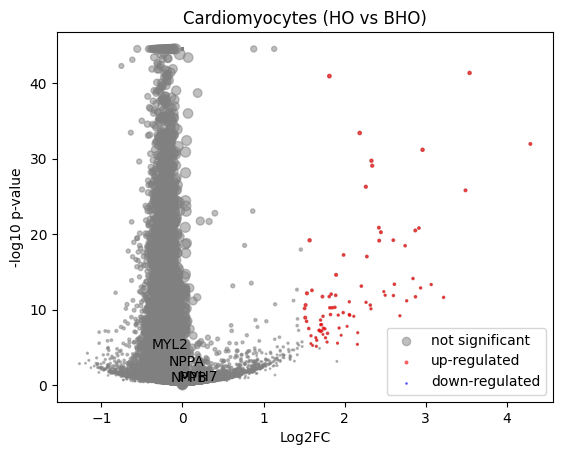

In [49]:
volcano_plot(adata_HO, 
             adata_BHO, 
             'cardio', 
             'Cardiomyocytes (HO vs BHO)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{OUT_DIR}/volcano/cardio.HO.BHO.png', 
             save_tsv=f'{OUT_DIR}/volcano/cardio.HO.BHO.tsv')

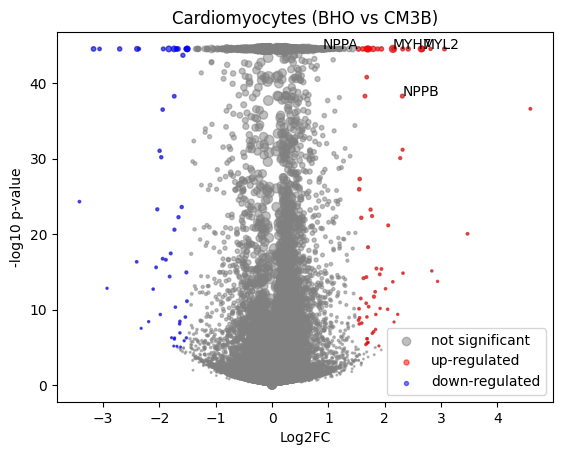

In [48]:
volcano_plot(adata_BHO, 
             adata_CM3B, 
             'cardio', 
             'Cardiomyocytes (BHO vs CM3B)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{OUT_DIR}/volcano/cardio.BHO.CM3B.png', 
             save_tsv=f'{OUT_DIR}/volcano/cardio.BHO.CM3B.tsv')

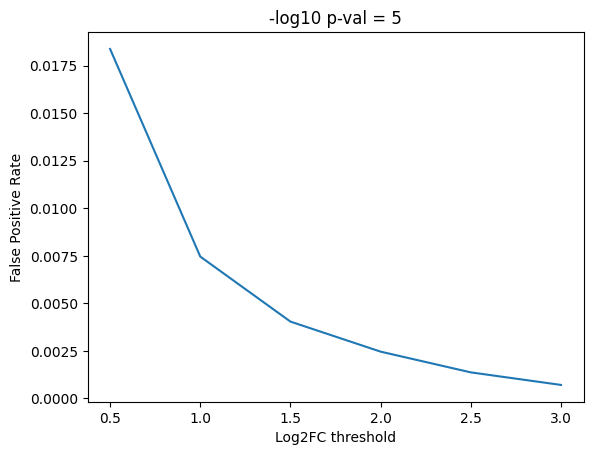

In [47]:
Log2FC = [0.5, 1, 1.5, 2, 2.5, 3]
FPR = [0.01838, 0.00746, 0.00404, 0.00246, 0.00137, 0.00071]

plt.plot(Log2FC, FPR)
plt.xlabel('Log2FC threshold')
plt.ylabel('False Positive Rate')
plt.title('-log10 p-val = 5')
plt.show()

### 4.4 draw maturation on UMAP

In [ ]:
celltypes_dict = {
    '0': 'cardio', 
    '1': 'cardio',
    '2': 'cardio',
    '3': 'peri',
    '4': 'endo',
    '5': 'peri',
    '6': 'cardio',
    '7': 'other',
    '8': 'other',
    '9': 'peri',
    '10': 'cardio',
    '11': 'cardio',
    '12': 'other',
    '13': 'other',
    '14': 'cardio',
    '15': 'other',
    '16': 'cardio',
    '17': 'cardio',
    '18': 'other',
    '19': 'peri',
}
samples = [adata_BVO, adata_HO, adata_CM3O, adata_BHO, adata_CM3B]

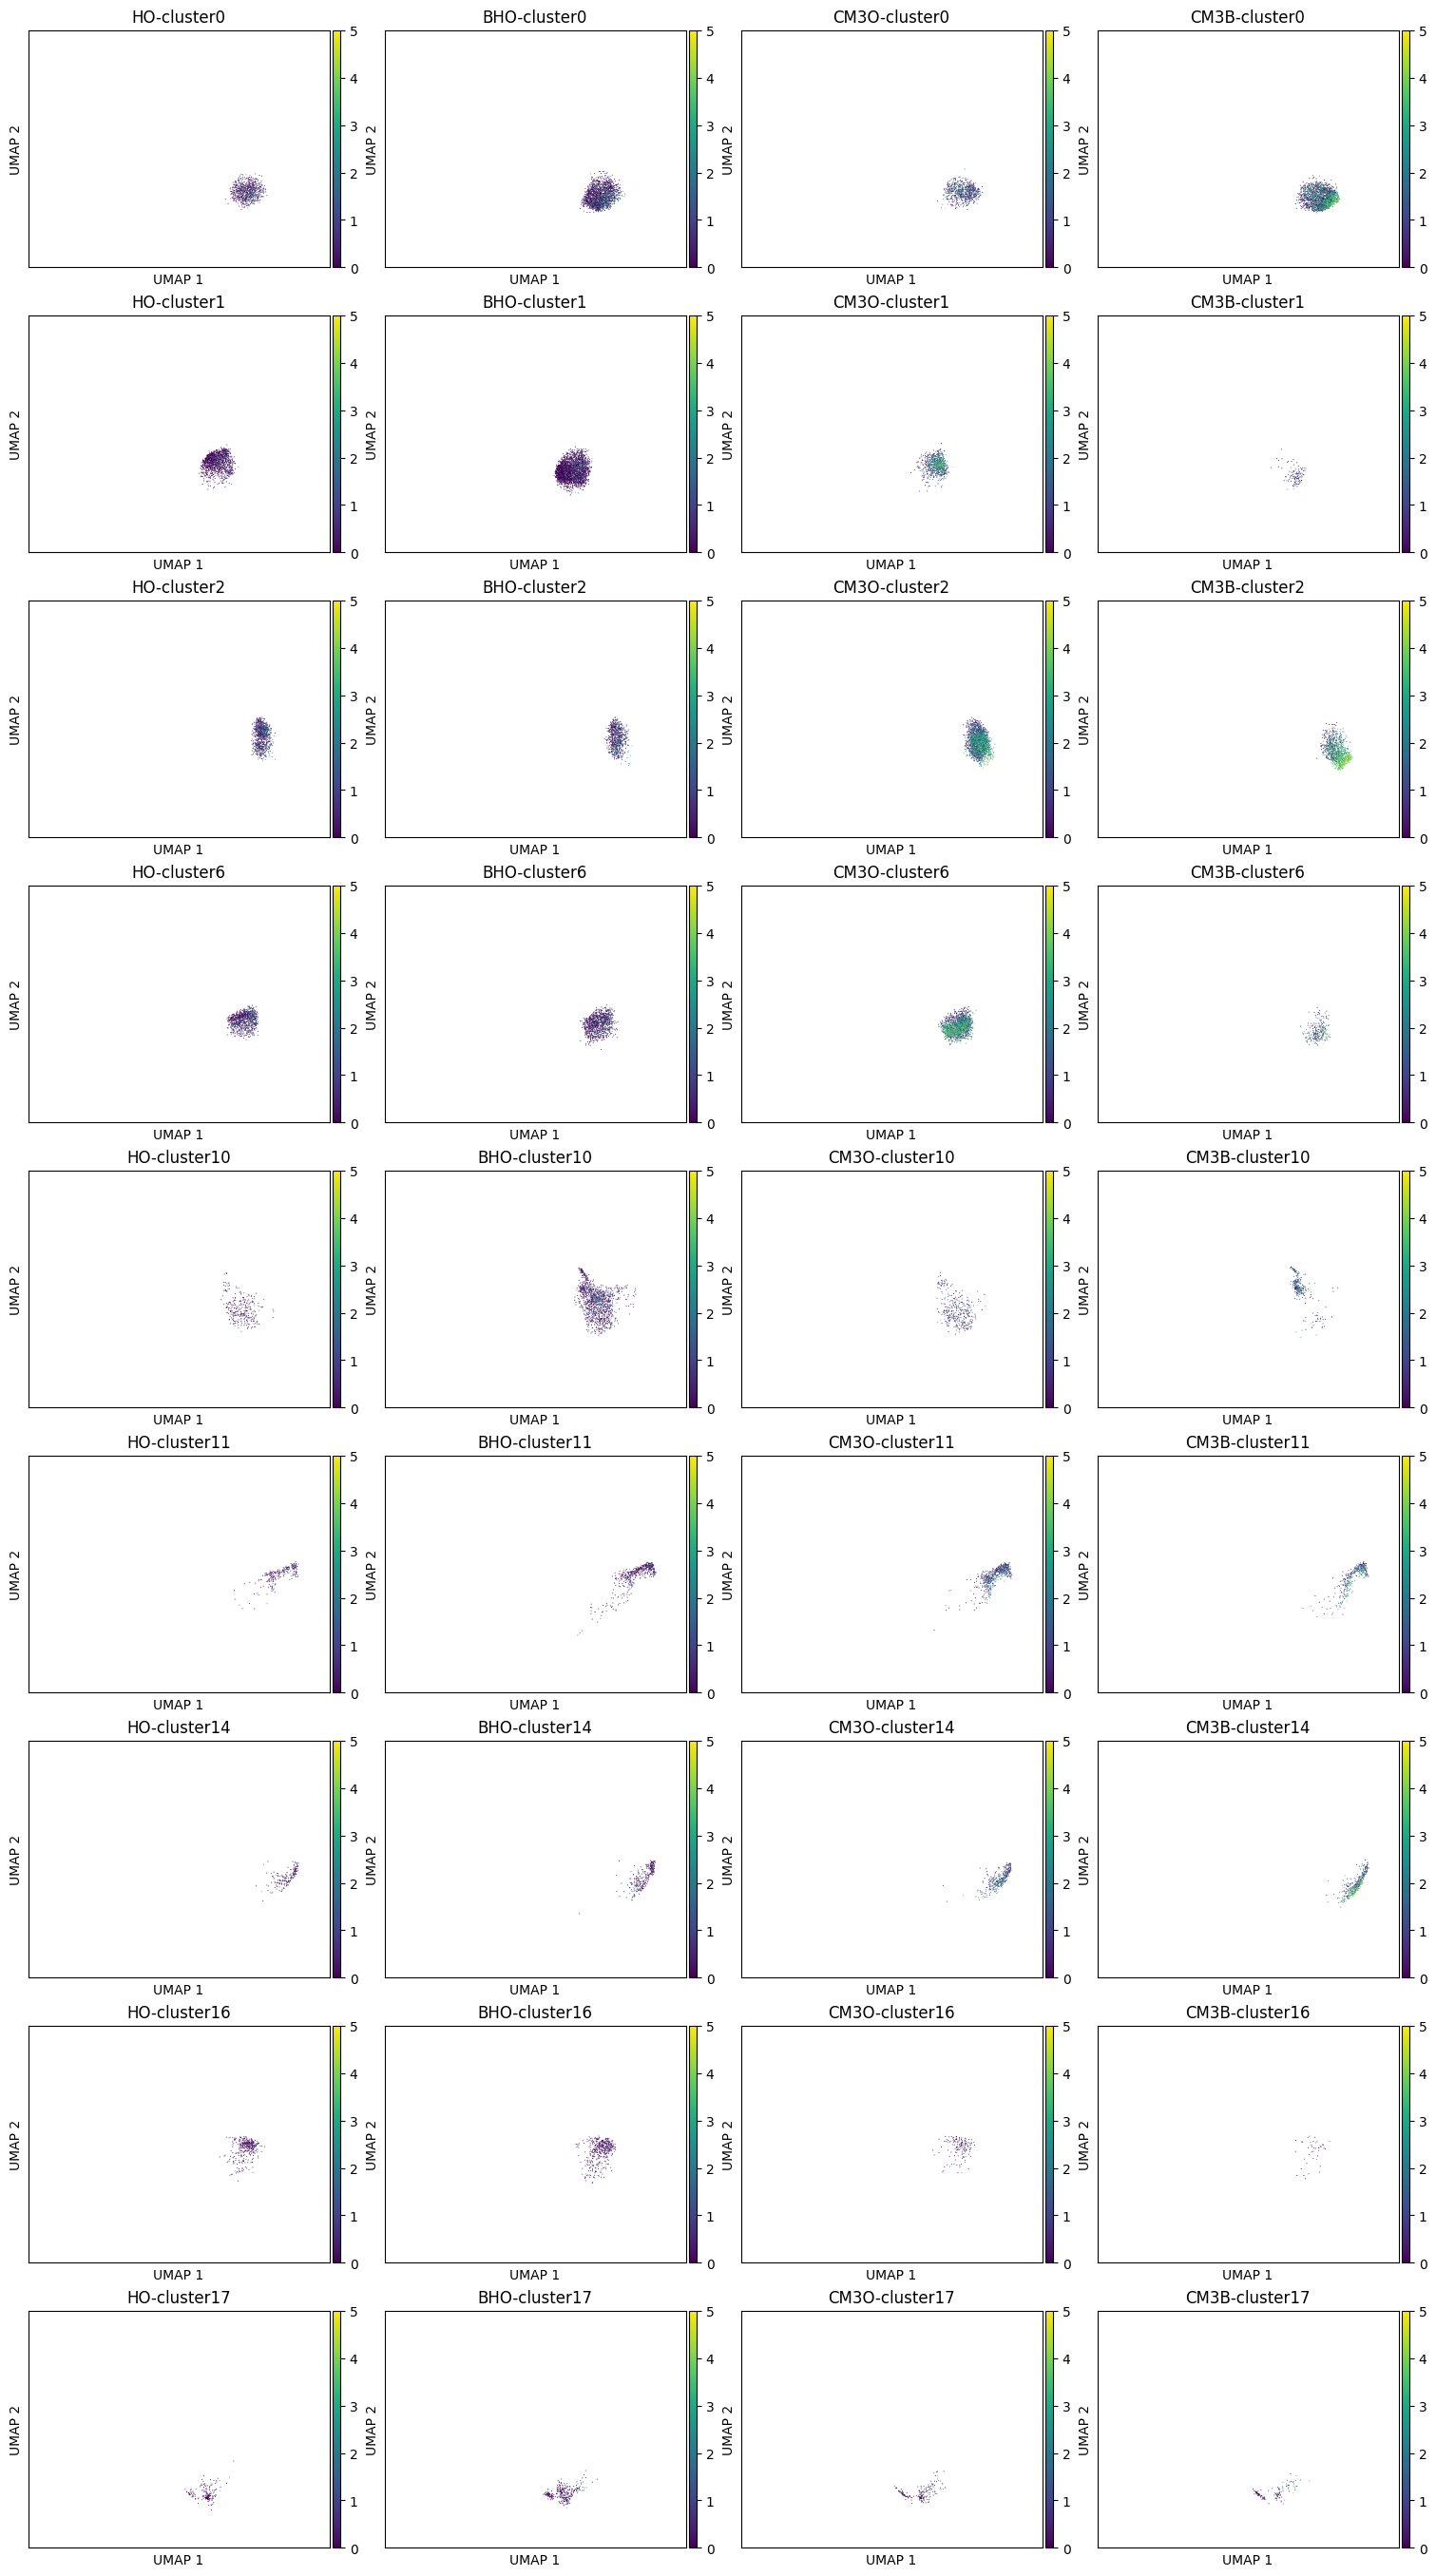

In [63]:
samples = [adata_HO, adata_BHO, adata_CM3O, adata_CM3B]
# clusters = ['0', '1']
clusters = ['0', '1', '2', '6', '10', '11', '14', '16', '17']
sample_names = ['HO','BHO','CM3O','CM3B']

fig, axs = plt.subplots(len(clusters), len(samples), figsize=(15,len(clusters)*3), layout="constrained")
# axs = axs.flatten()
# axs[-1].remove()

for i, adata in enumerate(samples):
    for j, ct in enumerate(clusters):
        # axs[j,i].scatter(adata[adata.obs['leiden'] == ct].obsm['X_umap'][:,0], adata[adata.obs['leiden'] == ct].obsm['X_umap'][:,1])
        axs[j,i] = sc.pl.umap(adata[adata.obs['leiden'] == ct], ax=axs[j,i], show=False, color='MYH7', vmax=5, vmin=0, s=2, title=f'{sample_names[i]}-cluster{clusters[j]}')
        
        axs[j,i].set_xlabel('UMAP 1')
        axs[j,i].set_ylabel('UMAP 2')
        axs[j,i].set_xlim([-10, 20])
        axs[j,i].set_ylim([-5, 15])
    
plt.show()

In [73]:
# samples = [adata_HO, adata_BHO, adata_CM3O, adata_CM3B]
# # clusters = ['0', '1']
# clusters = ['0', '1', '2', '6', '10', '11', '14', '16', '17']
# sample_names = ['HO','BHO','CM3O','CM3B']

# fig, axs = plt.subplots(len(clusters), len(samples), figsize=(15,len(clusters)*3), layout="constrained")
# # axs = axs.flatten()
# # axs[-1].remove()

# for i, adata in enumerate(samples):
#     for j, ct in enumerate(clusters):
#         # axs[j,i].scatter(adata[adata.obs['leiden'] == ct].obsm['X_umap'][:,0], adata[adata.obs['leiden'] == ct].obsm['X_umap'][:,1])
#         axs[j,i] = sc.pl.umap(adata[adata.obs['leiden'] == ct], ax=axs[j,i], show=False, color='MYL2', vmax=5, vmin=0, s=2, title=f'{sample_names[i]}-cluster{clusters[j]}')
        
#         axs[j,i].set_xlabel('UMAP 1')
#         axs[j,i].set_ylabel('UMAP 2')
#         axs[j,i].set_xlim([-10, 20])
#         axs[j,i].set_ylim([-5, 15])
    
# plt.show()

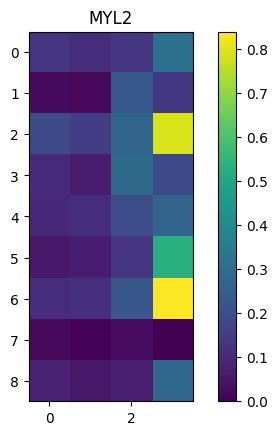

In [74]:
samples = [adata_HO, adata_BHO, adata_CM3O, adata_CM3B]
clusters = ['0', '1', '2', '6', '10', '11', '14', '16', '17']
sample_names = ['HO','BHO','CM3O','CM3B']

hm = np.zeros((len(clusters), len(samples)))

for i, adata in enumerate(samples):
    for j, ct in enumerate(clusters):
        hm[j, i] = adata[adata.obs['leiden'] == ct][:, adata.var_names == 'MYL2'].X.mean()
    
plt.imshow(hm)
plt.title('MYL2')
plt.colorbar()
plt.show()

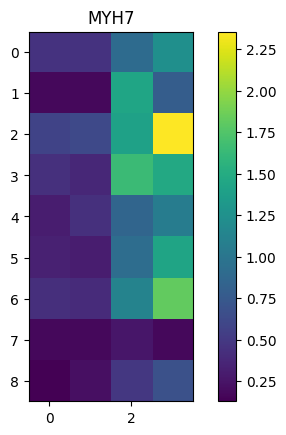

In [75]:
samples = [adata_HO, adata_BHO, adata_CM3O, adata_CM3B]
clusters = ['0', '1', '2', '6', '10', '11', '14', '16', '17']
sample_names = ['HO','BHO','CM3O','CM3B']

hm = np.zeros((len(clusters), len(samples)))

for i, adata in enumerate(samples):
    for j, ct in enumerate(clusters):
        hm[j, i] = adata[adata.obs['leiden'] == ct][:, adata.var_names == 'MYH7'].X.mean()
    
plt.imshow(hm)
plt.title('MYH7')
plt.colorbar()
plt.show()

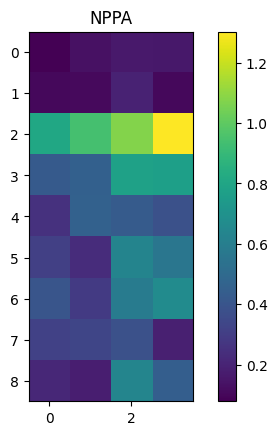

In [79]:
samples = [adata_HO, adata_BHO, adata_CM3O, adata_CM3B]
clusters = ['0', '1', '2', '6', '10', '11', '14', '16', '17']
sample_names = ['HO','BHO','CM3O','CM3B']

hm = np.zeros((len(clusters), len(samples)))

for i, adata in enumerate(samples):
    for j, ct in enumerate(clusters):
        hm[j, i] = adata[adata.obs['leiden'] == ct][:, adata.var_names == 'NPPA'].X.mean()
    
plt.imshow(hm)
plt.title('NPPA')
plt.colorbar()
plt.show()

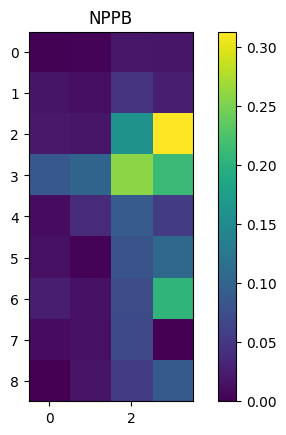

In [78]:
samples = [adata_HO, adata_BHO, adata_CM3O, adata_CM3B]
clusters = ['0', '1', '2', '6', '10', '11', '14', '16', '17']
sample_names = ['HO','BHO','CM3O','CM3B']

hm = np.zeros((len(clusters), len(samples)))

for i, adata in enumerate(samples):
    for j, ct in enumerate(clusters):
        hm[j, i] = adata[adata.obs['leiden'] == ct][:, adata.var_names == 'NPPB'].X.mean()
    
plt.imshow(hm)
plt.title('NPPB')
plt.colorbar()
plt.show()